### Needs to be executed in decoupler_liana environment

In [19]:
# Import Libraries
import scanpy as sc
import liana as li
from pycirclize import Circos
import pandas as pd
import matplotlib.pyplot as plt
from xlrd import colname

In [23]:
# Set Paths
project_path = "/home/usuario/PROJECTS/260724_victor_scRNA/"
results_path = project_path + "results/"
results_GEMX_CC_path = results_path + "GEMX/DecontX/CellCommunication/"

In [24]:
# Load Annotated Data in .h5ad Format
adata = sc.read_h5ad(results_GEMX_CC_path + "fully_annotated_data.h5ad")

In [ ]:
# Execute LIANA
li.mt.rank_aggregate(adata, groupby="celltype", resource_name="consensus",
                       expr_prop=0.1, layer="data_RNA_decontX", use_raw=False, verbose=True)
liana_res = adata.uns["liana_res"]

In [27]:
liana_res.to_csv(results_GEMX_CC_path+'liana.tsv', sep="\t", index=True)

In [35]:
liana_res = pd.read_csv(results_GEMX_CC_path+'liana.tsv', sep="\t", index_col=0)

In [52]:
def plot_chord(matrix, title):
    circos = Circos.chord_diagram(
        matrix,
        space=3,
        cmap="tab20",
        label_kws=dict(size=10, r=105, orientation="vertical"),
        link_kws=dict(ec="black", lw=0.3, direction=1),
    )
    fig = circos.plotfig()
    fig.suptitle(title, y=1.02)
    fig.savefig(results_GEMX_CC_path+title, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def build_interaction_matrix(res_df, sig_col="magnitude_rank", sig_thresh=0.05):
    sig = res_df[res_df[sig_col] < sig_thresh]
    counts = sig.groupby(["source", "target"]).size().reset_index(name="n_interactions")
    matrix = counts.pivot(index="source", columns="target", values="n_interactions").fillna(0)
    return matrix

In [74]:
celltypes = list(set(liana_res["source"]) | set(liana_res["target"]))

magnitude_matrix = build_interaction_matrix(liana_res, "magnitude_rank", sig_thresh=0.05)
specificity_matrix = build_interaction_matrix(liana_res, "specificity_rank", sig_thresh=0.05)

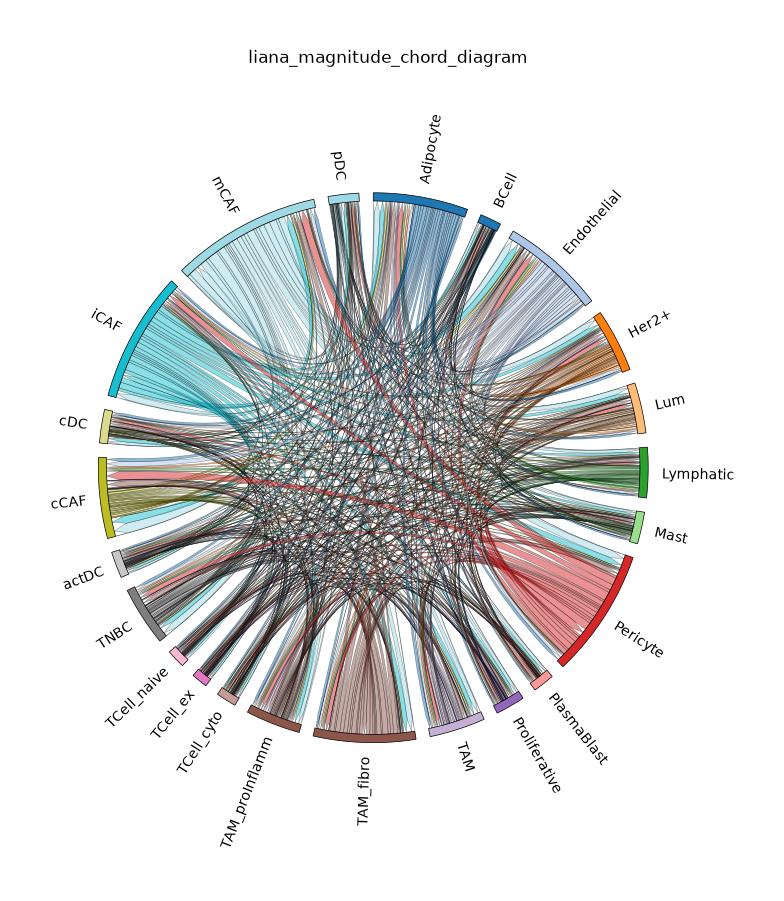

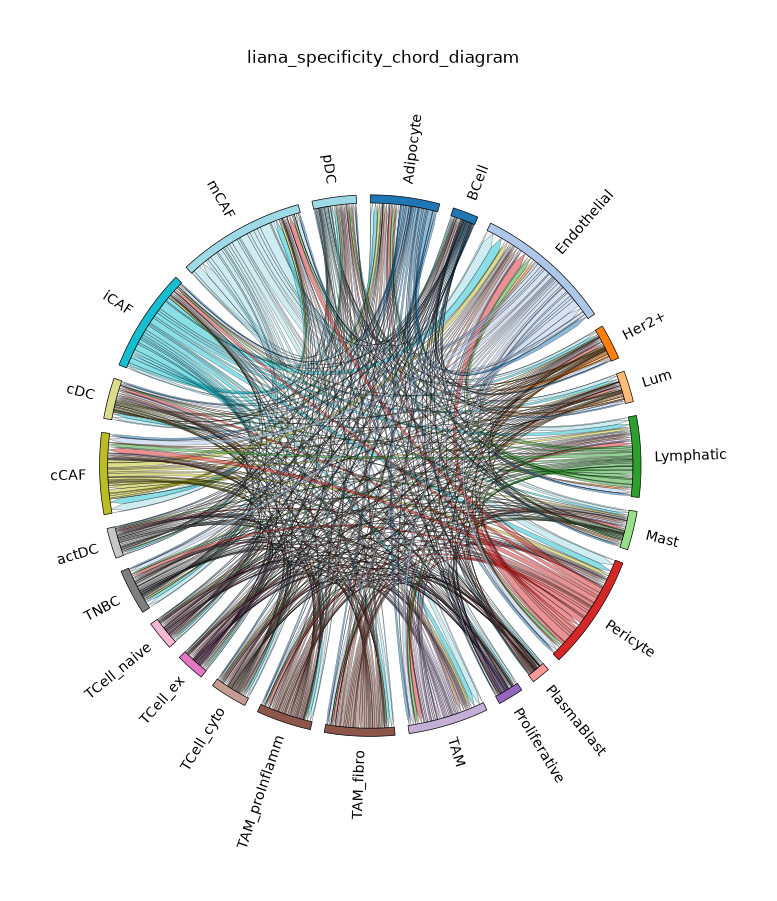

In [66]:
# Magnitude ChordPlot w/ all the Data
plot_chord(magnitude_matrix, "liana_magnitude_chord_diagram")

# Specificity ChordPlot w/ all the Data
plot_chord(specificity_matrix, "liana_specificity_chord_diagram")

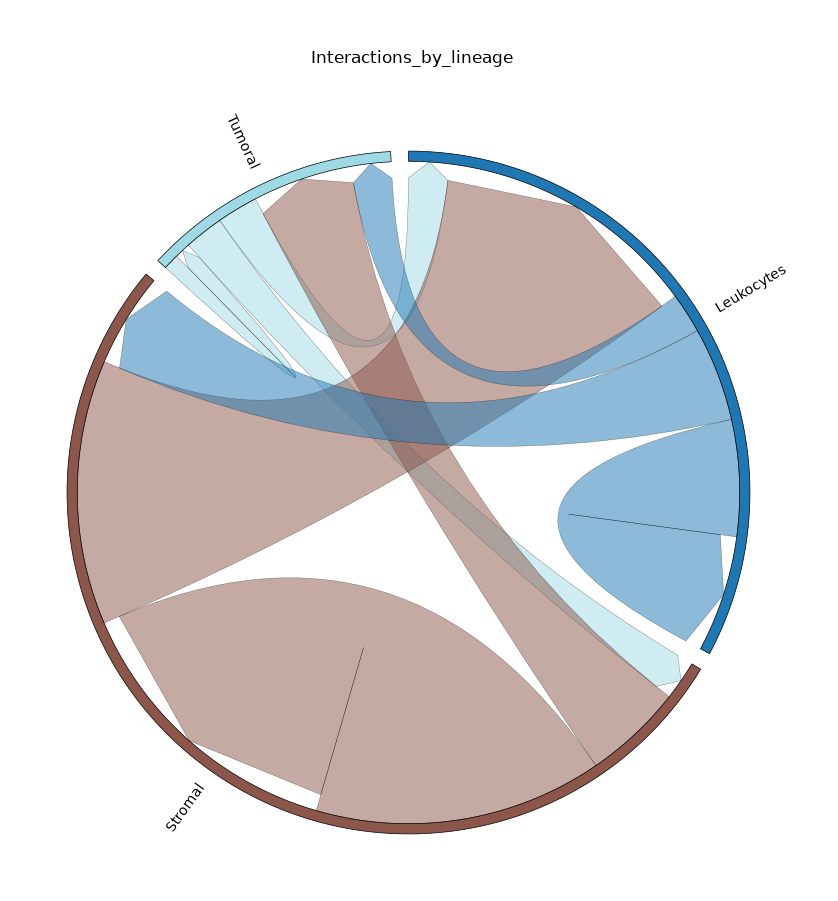

In [80]:
lineage_map = {
    "TCell_naive": "Leukocytes", "TCell_cyto": "Leukocytes", "TCell_ex": "Leukocytes",
    "BCell": "Leukocytes", "PlasmaBlast": "Leukocytes", "TAM": "Leukocytes",
    "TAM_fibro": "Leukocytes", "TAM_proInflamm": "Leukocytes",
    "pDC": "Leukocytes", "actDC": "Leukocytes", "cDC": "Leukocytes", "Mast": "Leukocytes",
    "Proliferative": "Leukocytes", "Lymphatic": "Stromal",
    "mCAF": "Stromal", "cCAF": "Stromal", "Endothelial": "Stromal",
    "Adipocyte": "Stromal", "iCAF": "Stromal", "Pericyte": "Stromal",
    "Lum": "Tumoral", "Her2+": "Tumoral", "TNBC": "Tumoral",
}

liana_res_lineage = liana_res.copy()
liana_res_lineage["source"] = liana_res_lineage["source"].map(lineage_map)
liana_res_lineage["target"] = liana_res_lineage["target"].map(lineage_map)

lineage_matrix = build_interaction_matrix(liana_res_lineage, "magnitude_rank", sig_thresh=0.05)

plot_chord(lineage_matrix, "Interactions_by_lineage")


In [81]:
def filter_by_genes(genes, name):
    res_filtered = liana_res[
        liana_res["ligand_complex"].isin(genes) | liana_res["receptor_complex"].isin(genes)
    ]
    if res_filtered.empty:
        print(f"No Interactions found for set: {name}")
        return
    matrix_filtered = build_interaction_matrix(res_filtered, "magnitude_rank", sig_thresh=0.05)
    plot_chord(matrix_filtered, f"Interactions_{name}")


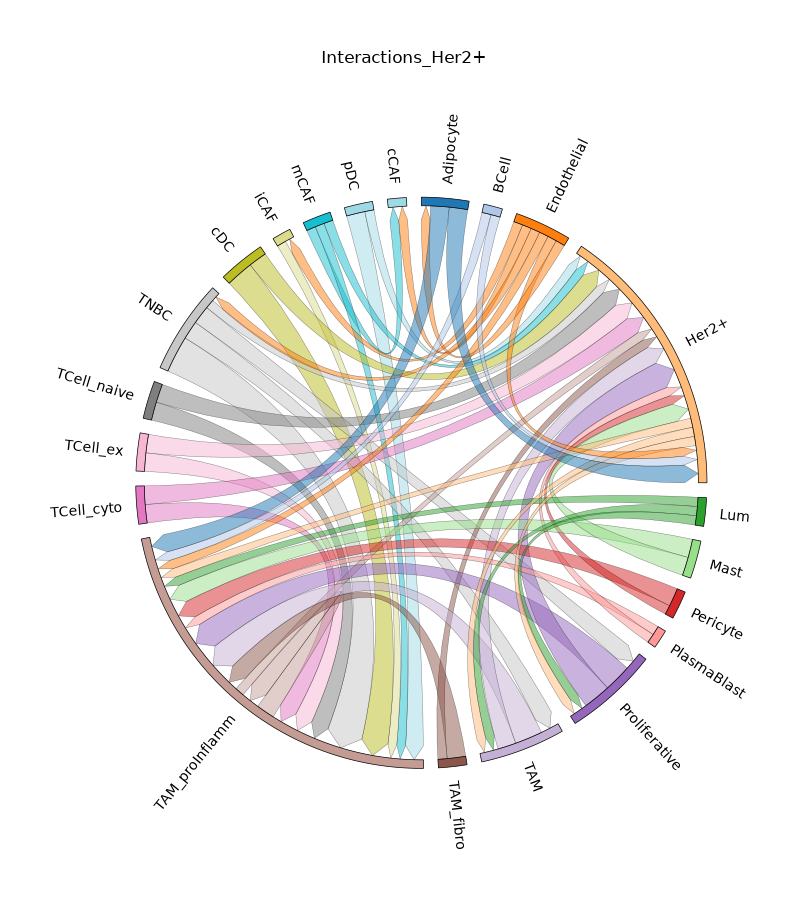

In [82]:
her2_egfr = ["EGF", "NRG1", "EGFR", "ERBB2", "ERBB3"]
filter_by_genes(her2_egfr, "Her2+")